# Import Libraries

In [4]:
import os

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE



In [5]:
cd ..

c:\Users\Lenovo\Desktop\Tourist Attraction Recommendation System


c:\Users\Lenovo\Desktop\Tourist Attraction Recommendation System\venv\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [6]:
# # Loading all the cleaned data in different csv files
# # Specify the folder containing the CSV files
# folder_path = 'Dataset/Cleaned'

# # Initialize an empty list to store DataFrames
# dataframes = []

# # Iterate over each file in the folder
# for file_name in os.listdir(folder_path):
#     if file_name.endswith('.csv'):  # Check if the file is a CSV
#         file_path = os.path.join(folder_path, file_name)
#         df = pd.read_csv(file_path)  # Load CSV into a DataFrame
#         dataframes.append(df)  # Append the DataFrame to the list

# # Concatenate all DataFrames into one
# combined_df = pd.concat(dataframes, ignore_index=True)

# # Display the combined DataFrame
# print(combined_df)

combined_df = pd.read_csv("combined.csv")

In [7]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1240 entries, 0 to 1239
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   1240 non-null   int64  
 1   name         1240 non-null   object 
 2   description  1240 non-null   object 
 3   longitude    1240 non-null   float64
 4   latitude     1240 non-null   float64
 5   category     1240 non-null   object 
 6   country      1240 non-null   object 
dtypes: float64(2), int64(1), object(4)
memory usage: 67.9+ KB


In [9]:
top10_countries = combined_df['country'].value_counts().reset_index().head(10)
top10_countries

,country,count
0,Nepal,433
1,India,431
2,Indonesia,70
3,Malaysia,58
4,China,56
5,Singapore,26
6,Japan,24
7,Sri Lanka,16
8,Timor-Leste,14
9,Israel,9


In [10]:
#Clean the dataset
combined_df.dropna(subset = 'description',inplace=True)
combined_df.drop_duplicates(subset ='name',inplace= True)
combined_df= combined_df.reset_index(drop=True)
combined_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1240 entries, 0 to 1239
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   1240 non-null   int64  
 1   name         1240 non-null   object 
 2   description  1240 non-null   object 
 3   longitude    1240 non-null   float64
 4   latitude     1240 non-null   float64
 5   category     1240 non-null   object 
 6   country      1240 non-null   object 
dtypes: float64(2), int64(1), object(4)
memory usage: 67.9+ KB


In [11]:
# df= combined_df.groupby('country')['name'].nunique()
#find number of unique countries
combined_df['country'].nunique()

36

In [12]:
#find the missing countries
asian_countries = [
    "Afghanistan", "Armenia", "Azerbaijan", "Bahrain", "Bangladesh", "Bhutan",
    "Brunei", "Cambodia", "China", "Cyprus", "Georgia", "India", "Indonesia",
    "Iran", "Iraq", "Israel", "Japan", "Jordan", "Kazakhstan", "Kuwait",
    "Kyrgyzstan", "Laos", "Lebanon", "Malaysia", "Maldives", "Mongolia",
    "Myanmar (Burma)", "Nepal", "North Korea", "Oman", "Pakistan", "Palestine",
    "Philippines", "Qatar", "Saudi Arabia", "Singapore", "South Korea",
    "Sri Lanka", "Syria", "Tajikistan", "Thailand", "Timor-Leste", "Turkey",
    "Turkmenistan", "United Arab Emirates", "Uzbekistan", "Vietnam", "Yemen"
]

df_set = set(combined_df['country'])
for Country in asian_countries:
    if Country not in df_set:
        print(Country)

Bhutan
Brunei
Iran
Kuwait
Laos
Maldives
Myanmar (Burma)
North Korea
South Korea
Syria
Turkey
Vietnam


In [13]:
df = combined_df[combined_df['country'] == 'Nepal'].reset_index()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 433 entries, 0 to 432
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   index        433 non-null    int64  
 1   Unnamed: 0   433 non-null    int64  
 2   name         433 non-null    object 
 3   description  433 non-null    object 
 4   longitude    433 non-null    float64
 5   latitude     433 non-null    float64
 6   category     433 non-null    object 
 7   country      433 non-null    object 
dtypes: float64(2), int64(2), object(4)
memory usage: 27.2+ KB


In [14]:
top10_countries = combined_df['country'].value_counts().reset_index().head(10)
top10_countries

,country,count
0,Nepal,433
1,India,431
2,Indonesia,70
3,Malaysia,58
4,China,56
5,Singapore,26
6,Japan,24
7,Sri Lanka,16
8,Timor-Leste,14
9,Israel,9


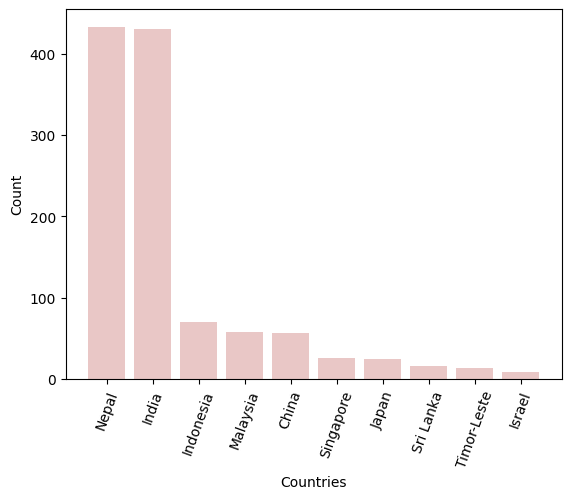

In [16]:
plt.bar(top10_countries['country'], top10_countries['count'], color = '#E9C7C6')
plt.xlabel("Countries")
plt.xticks(rotation=70, horizontalalignment="center")
plt.ylabel("Count")
plt.show()

In [17]:
# Vectorize 'Description' column using TF-IDF
tfidf = TfidfVectorizer(stop_words='english', max_features=100)
description_vectors = tfidf.fit_transform(combined_df['description']).toarray()


In [19]:

# One-hot encode 'Category'
encoder = OneHotEncoder()
category_encoded = encoder.fit_transform(combined_df[['category']]).toarray()

In [20]:
# Combine Latitude, Longitude with encoded features and TF-IDF vectors
geo_features = combined_df[['latitude', 'longitude']].values
geo_weight = 0.5
desc_weight = 1.5
category_weight = 1.0

weighted_features = np.hstack((
    geo_features * geo_weight,
    category_encoded * category_weight,
    description_vectors * desc_weight
))


In [21]:
# Compute similarity between places
similarity_matrix = cosine_similarity(weighted_features)

In [22]:
# Get recommendations for a specific place (e.g., index 0)
place_index = 123
similar_places = np.argsort(-similarity_matrix[place_index])[1:6]  # Top 5 excluding itself
similar_places


array([100, 184, 189, 216, 136])

In [23]:
print(combined_df.iloc[similar_places])


     Unnamed: 0           name  \
100         100         Dakmar   
184         184     Sadda Pind   
189         189  Sentinel peak   
216         216   crystal peak   
136         136       Kalāttip   

                                           description  longitude   latitude  \
100               path going to Dakmar meditation cave  77.057342  34.332248   
184  Recreated Punjabi village with activities and ...  74.812824  31.643733   
189                 first ascent: john jackson in 1945  75.133223  34.199445   
216                                               peak  75.321665  34.223939   
136                  It is a peak in kashmir hinalayas  75.464838  34.043221   

               category country  
100  Tourist Attraction   India  
184  Tourist Attraction   India  
189    Natural Landmark   India  
216    Natural Landmark   India  
136    Natural Landmark   India  


In [26]:
indices = pd.Series(combined_df.index, index=combined_df['name']).drop_duplicates()


In [27]:
def content_recommender(title, cosine_sim=similarity_matrix, df=df,
indices=indices):
    # Obtain the index of the attraction that matches the title
    idx = indices[title]
    # Get the pairwsie similarity scores of all attraction with that attraction
    # And convert it into a list of tuples as described above
    sim_scores = list(enumerate(cosine_sim[idx]))
    # Sort the attractions based on the cosine similarity scores
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    # Get the scores of the 10 most similar attraction. Ignore the first movie.
    sim_scores = sim_scores[1:11]
    # Get the attraction indices
    attraction_indices = [i[0] for i in sim_scores]
    # Return the top 10 most similar attraction
    return combined_df.iloc[attraction_indices]

In [29]:
print(combined_df[combined_df["name"]== "Attayam Chira"])


    Unnamed: 0           name description  longitude   latitude  \
78          78  Attayam Chira  Water Fall  76.594083  10.004348   

              category country  
78  Tourist Attraction   India  


In [30]:
content_recommender("Attayam Chira")

,Unnamed: 0,name,description,longitude,latitude,category,country
181,181,Roaduvila Irappu para waterfalls,A nice stream and waterfall,76.814008,8.867840,Tourist Attraction,India
958,958,Cellular Jail,"The Cellular Jail, also known as 'Kālā Pānī' (...",92.747786,11.674446,Landmark,India
221,221,உபகார மாதா ஆலயம்,www.facebook.com/navamudalur/,77.945701,8.417446,Tourist Attraction,India
222,222,சின்ன தும்கல் நீர் வீழ்ச்சி (thumkal water falls),Seasonal Waterfalls,77.915037,12.171014,Tourist Attraction,India
110,110,Dolmen Peak,360 degree views,77.513589,10.298477,Natural Landmark,India
219,219,meenuliyanpara,Elevation above sea level: 891 Mtr,76.865654,10.000775,Natural Landmark,India
180,180,Ridge Point,Ridge Point,75.712395,12.731323,Tourist Attraction,India
202,202,Temple Rooftop View Point,"20Rs entry, camera 50Rs",78.689874,10.861242,Scenic View,India
152,152,"MalaManda, the Mountain Camp",Camp Ground,76.937533,9.602461,Natural Landmark,India
209,209,Valaukuparai,just a break point in trek,78.308696,11.079925,Scenic View,India


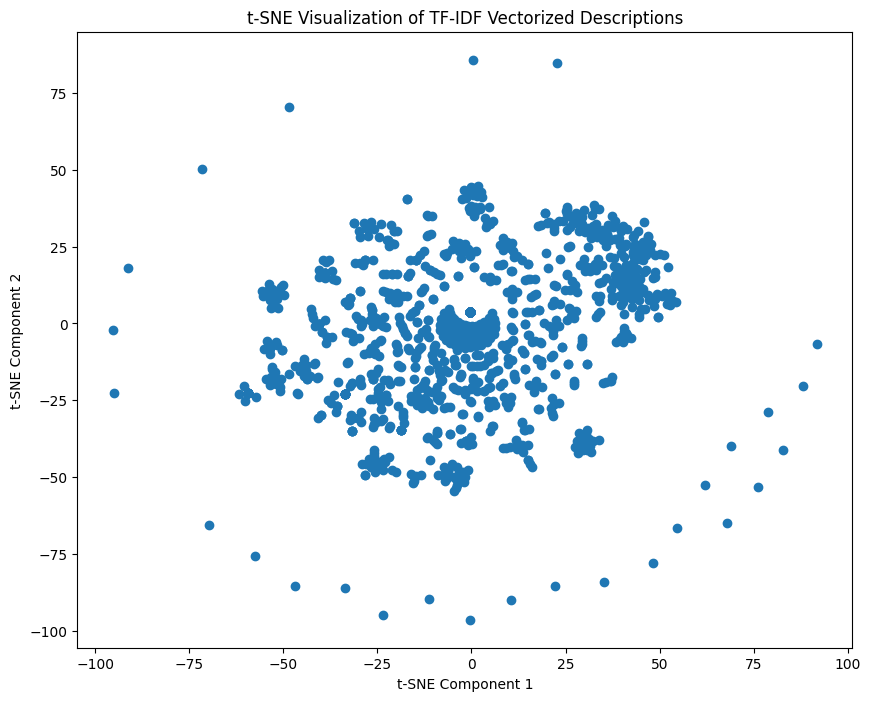

In [31]:

def visualize_tfidf_tsne(description_vectors):
    # Step 1: Perform t-SNE to reduce the dimensionality of the TF-IDF vectors to 2D
    tsne = TSNE(n_components=2, random_state=0)
    reduced_vectors = tsne.fit_transform(description_vectors)

    # Step 2: Plot the 2D projections of the TF-IDF vectors
    plt.figure(figsize=(10, 8))
    plt.scatter(reduced_vectors[:, 0], reduced_vectors[:, 1])
    plt.title("t-SNE Visualization of TF-IDF Vectorized Descriptions")
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.show()

# Example usage with your pre-existing description_vectors
visualize_tfidf_tsne(description_vectors)